# App Product Interest Analysis

상품 매칭 및 비정상 사용자 제거가 끝난 앱 이벤트를 바탕으로, 상품 관심도 분석 결과를 단계별로 확인하는 노트북입니다.

- 입력 데이터: `outputs/cleaned_app_events/clean_app_item_interactions.parquet`
- 분석 모듈: `app_product_interest_analysis.py`
- 결과 위치: `outputs/product_interest_analysis/`
- 주의: 현재 매칭된 상품 이벤트에는 구매 이벤트가 없으므로, 아래 지표는 매출 전환이 아니라 앱 내 관심도와 구매 의도 proxy입니다.

## 0. 환경 준비

분석 모듈을 불러오고 결과 저장 폴더를 준비합니다. 이 셀은 데이터 파일을 수정하지 않고, EDA 출력 폴더만 생성합니다.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

BASE_DIR = Path.cwd()
if not (BASE_DIR / "app_product_interest_analysis.py").exists():
    BASE_DIR = Path.cwd() / "eda" / "app_event_yumi"

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

analysis = importlib.import_module("app_product_interest_analysis")
analysis = importlib.reload(analysis)

OUTPUT_DIR = analysis.OUTPUT_DIR
MONTH_DIR = analysis.MONTH_DIR
PERIOD_DIR = analysis.PERIOD_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MONTH_DIR.mkdir(parents=True, exist_ok=True)
PERIOD_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

BASE_DIR, analysis.INPUT_FILE, OUTPUT_DIR

(PosixPath('/Users/yumi/Seven-eleven/eda/app_event_yumi'),
 PosixPath('/Users/yumi/Seven-eleven/eda/app_event_yumi/outputs/cleaned_app_events/clean_app_item_interactions.parquet'),
 PosixPath('/Users/yumi/Seven-eleven/eda/app_event_yumi/outputs/product_interest_analysis'))

## 1. 데이터 로드 확인

클린 상품 이벤트 parquet을 LazyFrame으로 연결하고, 컬럼 스키마를 먼저 확인합니다.

In [2]:
lf = analysis.app_lf()
lf.collect_schema()

Schema([('event_date', Date),
        ('event_month', String),
        ('event_hour', Int8),
        ('Event Time', String),
        ('Event Name', String),
        ('event_weight', Float64),
        ('af_customer_user_id', String),
        ('AppsFlyer ID', String),
        ('platform_norm', String),
        ('media_source_norm', String),
        ('campaign_norm', String),
        ('online_item_code', String),
        ('mapped_pos_item_code', String),
        ('mapped_item_name', String),
        ('item_type', String),
        ('mapped_category_hierarchy', String),
        ('category_l', String),
        ('category_m', String),
        ('category_s', String),
        ('list_price', Int64)])

## 2. 전체 개요

분석 대상 이벤트 수, 상품 수, 사용자 수, 카테고리 수, 관측 기간을 확인합니다.

In [3]:
overview = lf.select(
    [
        analysis.pl.len().alias("clean_product_event_rows"),
        analysis.pl.col("mapped_pos_item_code").n_unique().alias("unique_products"),
        analysis.pl.col("af_customer_user_id").n_unique().alias("unique_users"),
        analysis.pl.col("category_l").n_unique().alias("unique_large_categories"),
        analysis.pl.col("event_date").min().alias("start_date"),
        analysis.pl.col("event_date").max().alias("end_date"),
    ]
).collect()

analysis.write_csv(overview, "product_analysis_overview.csv")
overview

clean_product_event_rows,unique_products,unique_users,unique_large_categories,start_date,end_date
u32,u32,u32,u32,date,date
3176133,5351,205209,35,2025-03-01,2025-05-31


## 3. 상품 이벤트 믹스

`view`, `cart`, `wishlist`, `share`, `remove` 이벤트의 비중입니다. 구매 이벤트가 없으므로 장바구니와 위시리스트를 구매 의도 proxy로 봅니다.

In [4]:
event_mix = (
    lf.group_by("Event Name")
    .agg(analysis.pl.len().alias("event_count"))
    .with_columns(
        (analysis.pl.col("event_count") / analysis.pl.col("event_count").sum() * 100)
        .round(4)
        .alias("event_share_pct")
    )
    .sort("event_count", descending=True)
    .collect()
)

analysis.write_csv(event_mix, "product_event_mix.csv")
event_mix

Event Name,event_count,event_share_pct
str,u32,f64
"""af_content_view_product""",2443032,76.9184
"""af_add_to_cart""",490142,15.432
"""af_remove_from_cart""",110263,3.4716
"""af_add_to_wishlist""",108734,3.4235
"""af_remove_from_wishlist""",22393,0.705
"""af_share""",1569,0.0494


## 4. 상품별 관심도 지표

`intent_score`는 조회, 장바구니, 위시리스트, 공유를 가중 합산하고 삭제 이벤트를 차감한 앱 관심도 지표입니다.

In [5]:
products = analysis.product_metrics(lf)
analysis.write_csv(products, "product_interest_metrics.csv")
analysis.write_csv(products.head(200), "top200_products_by_intent_score.csv")

product_cols = [
    "mapped_pos_item_code",
    "mapped_item_name",
    "mapped_category_hierarchy",
    "unique_users",
    "view_count",
    "cart_add_count",
    "wishlist_add_count",
    "share_count",
    "intent_score",
    "cart_add_per_100_views",
    "intent_score_per_user",
]
products.select(product_cols).head(30)

mapped_pos_item_code,mapped_item_name,mapped_category_hierarchy,unique_users,view_count,cart_add_count,wishlist_add_count,share_count,intent_score,cart_add_per_100_views,intent_score_per_user
str,str,str,u32,i64,i64,i64,i64,i64,f64,f64
"""125340""","""KBO)롯데자이언츠거인단팥빵100g""","""빵>간식빵>캐릭터빵""",29329,204762,33271,6971,24,313383,16.2486,10.6851
"""125435""","""KBO)롯데자이언츠씨앗호떡빵97g""","""빵>간식빵>캐릭터빵""",21196,100221,18870,5497,9,164348,18.8284,7.7537
"""123101""","""G)오하요저지우유푸딩115g""","""디저트>젤리>푸딩""",24953,87983,13286,3185,60,132272,15.1006,5.3008
"""123923""","""신동엽)블랙서클위스키700ml""","""양주와인>양주>위스키""",15445,92943,1519,2702,26,102042,1.6343,6.6068
"""125469""","""PB)자이언츠육각꼬깔콘군옥수수맛134g""","""과자>스낵류>옥수수스낵""",14976,61046,6582,4100,4,87411,10.782,5.8367
…,…,…,…,…,…,…,…,…,…,…
"""124530""","""최강록의간장들기름비빔밥""","""미반>도시락>기타""",5848,11631,2349,319,4,18764,20.196,3.2086
"""124677""","""KBO)삼립삼성라이온즈블루베리패스츄리100g""","""빵>간식빵>캐릭터빵""",4532,8853,2535,614,1,16962,28.6344,3.7427
"""014287""","""롯데)NEW참치마요네즈삼각""","""미반>삼각김밥>삼각김밥""",4153,7064,2958,138,4,16070,41.8743,3.8695


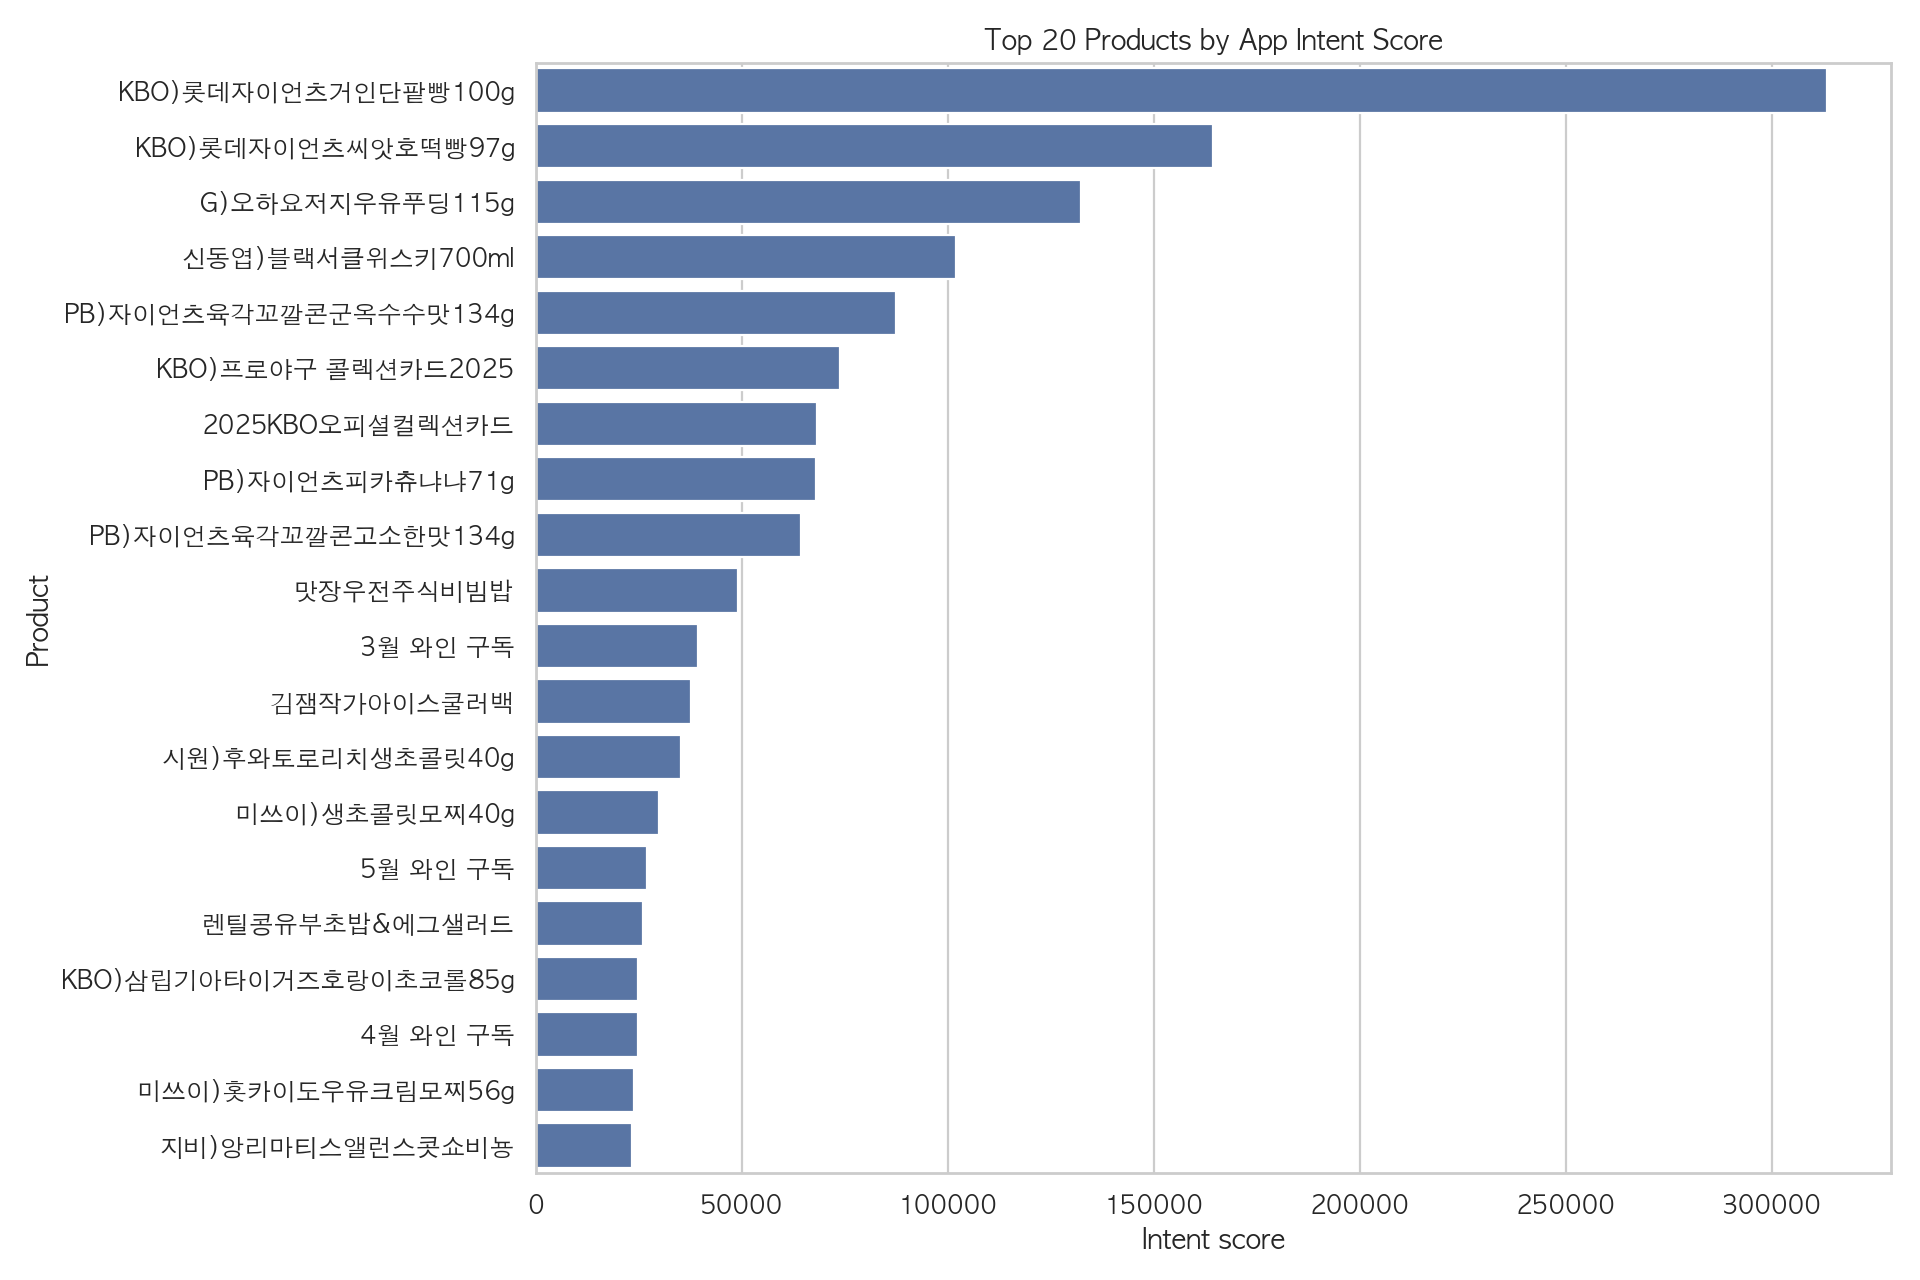

In [6]:
analysis.save_barplot(
    products.head(20),
    x="intent_score",
    y="mapped_item_name",
    title="Top 20 Products by App Intent Score",
    xlabel="Intent score",
    ylabel="Product",
    filename="top20_products_by_intent_score.png",
)

display(Image(filename=str(OUTPUT_DIR / "top20_products_by_intent_score.png")))

## 5. 장바구니 전환율 상위 상품

조회 수가 최소 500 이상인 상품 중 `cart_add_per_100_views`가 높은 상품입니다. 관심 규모보다 구매 의도 밀도를 확인할 때 사용합니다.

In [7]:
cart_rate = (
    products.sort("cart_add_per_100_views", descending=True)
    .filter(analysis.pl.col("view_count") >= 500)
    .head(200)
)
analysis.write_csv(cart_rate, "top200_products_by_cart_rate_min500views.csv")
cart_rate.select(product_cols).head(30)

mapped_pos_item_code,mapped_item_name,mapped_category_hierarchy,unique_users,view_count,cart_add_count,wishlist_add_count,share_count,intent_score,cart_add_per_100_views,intent_score_per_user
str,str,str,u32,i64,i64,i64,i64,i64,f64,f64
"""115858""","""농심)새우깡90g""","""과자>스낵류>일반스낵""",512,787,507,20,0,2192,64.4219,4.2812
"""132226""","""삼양)불닭볶음면(큰컵)""","""면>용기면>비빔/볶음면""",316,531,338,11,0,1481,63.6535,4.6867
"""115920""","""농심)매운새우깡90g""","""과자>스낵류>일반스낵""",449,673,427,18,0,1852,63.4473,4.1247
"""132145""","""농심)김치사발면""","""면>용기면>라면(소형컵)""",481,788,469,22,0,2089,59.5178,4.343
"""115848""","""에이스)옥수수브이콘50g""","""과자>스낵류>전통스낵""",537,784,461,37,0,2089,58.801,3.8901
…,…,…,…,…,…,…,…,…,…,…
"""600592""","""PB)왕소라형스낵143g""","""과자>스낵류>전통스낵""",507,768,395,26,0,1878,51.4323,3.7041
"""202136""","""코카)조지아블랙470ml""","""음료>커피음료>PET커피""",493,814,418,29,0,1993,51.3514,4.0426
"""123766""","""모바일금액권 30,000원""","""기타>판촉물>판촉물""",1371,2845,1459,69,5,7341,51.283,5.3545


## 6. 사용자 도달 상위 상품

`unique_users`가 큰 상품은 단순 관심 점수와 별개로 앱에서 넓게 노출되었거나 많은 사용자가 반응한 상품입니다.

In [8]:
user_reach = products.sort("unique_users", descending=True).head(200)
analysis.write_csv(user_reach, "top200_products_by_unique_users.csv")
user_reach.select(product_cols).head(30)

mapped_pos_item_code,mapped_item_name,mapped_category_hierarchy,unique_users,view_count,cart_add_count,wishlist_add_count,share_count,intent_score,cart_add_per_100_views,intent_score_per_user
str,str,str,u32,i64,i64,i64,i64,i64,f64,f64
"""125340""","""KBO)롯데자이언츠거인단팥빵100g""","""빵>간식빵>캐릭터빵""",29329,204762,33271,6971,24,313383,16.2486,10.6851
"""123101""","""G)오하요저지우유푸딩115g""","""디저트>젤리>푸딩""",24953,87983,13286,3185,60,132272,15.1006,5.3008
"""125435""","""KBO)롯데자이언츠씨앗호떡빵97g""","""빵>간식빵>캐릭터빵""",21196,100221,18870,5497,9,164348,18.8284,7.7537
"""125374""","""PB)자이언츠피카츄냐냐71g""","""과자>스낵류>옥수수스낵""",16548,46427,6263,2328,11,68083,13.49,4.1143
"""125500""","""김잼작가아이스쿨러백""","""일용잡화>취미용품>취미용품(구 취미실내)""",16221,29812,2238,573,148,37837,7.507,2.3326
…,…,…,…,…,…,…,…,…,…,…
"""105887""","""롯데)맛장우맛자랑 전주식비빔밥""","""미반>도시락>도시락""",4439,13091,2993,343,3,21452,22.863,4.8326
"""191866""","""5월 와인 구독""",null,4342,17780,2861,341,23,26972,16.0911,6.2119
"""192580""","""4월 와인 구독""",null,4339,15684,2740,459,28,24757,17.47,5.7057


## 7. 카테고리별 관심도

대분류/중분류 단위로 앱 관심도, 상품 수, 사용자 수, 장바구니 전환율을 확인합니다.

In [9]:
categories = analysis.category_metrics(lf)
analysis.write_csv(categories, "category_interest_metrics.csv")

category_cols = [
    "category_l",
    "category_m",
    "total_events",
    "unique_products",
    "unique_users",
    "weighted_interest_score",
    "view_count",
    "cart_add_count",
    "wishlist_add_count",
    "cart_add_per_100_views",
    "intent_actions_per_100_views",
    "score_per_product",
]
categories.select(category_cols).head(30)

category_l,category_m,total_events,unique_products,unique_users,weighted_interest_score,view_count,cart_add_count,wishlist_add_count,cart_add_per_100_views,intent_actions_per_100_views,score_per_product
str,str,u32,u32,u32,f64,i64,i64,i64,f64,f64,f64
"""빵""","""간식빵""",498413,105,45724,641943.5,386781,77557,18834,20.0519,24.9213,6113.7476
"""미반""","""도시락""",278825,65,35931,351662.5,211905,47247,5838,22.2963,25.0513,5410.1923
"""과자""","""스낵류""",272791,198,37875,344996.0,205973,42278,12227,20.526,26.4622,1742.404
"""양주와인""","""양주""",230111,290,26770,251798.0,209443,8954,8991,4.2751,8.568,868.269
null,null,136884,26,24595,179600.0,112567,20964,2411,18.6236,20.7654,6907.6923
…,…,…,…,…,…,…,…,…,…,…,…
"""미반""","""푸드 간편식""",27162,29,7303,32379.0,22030,3337,707,15.1475,18.3568,1116.5172
"""과자""","""젤리류""",24437,151,6284,31388.0,18833,3858,885,20.4853,25.1845,207.8675
"""양주와인""","""하이볼""",24996,29,6473,30647.5,19208,3300,1336,17.1803,24.1358,1056.8103


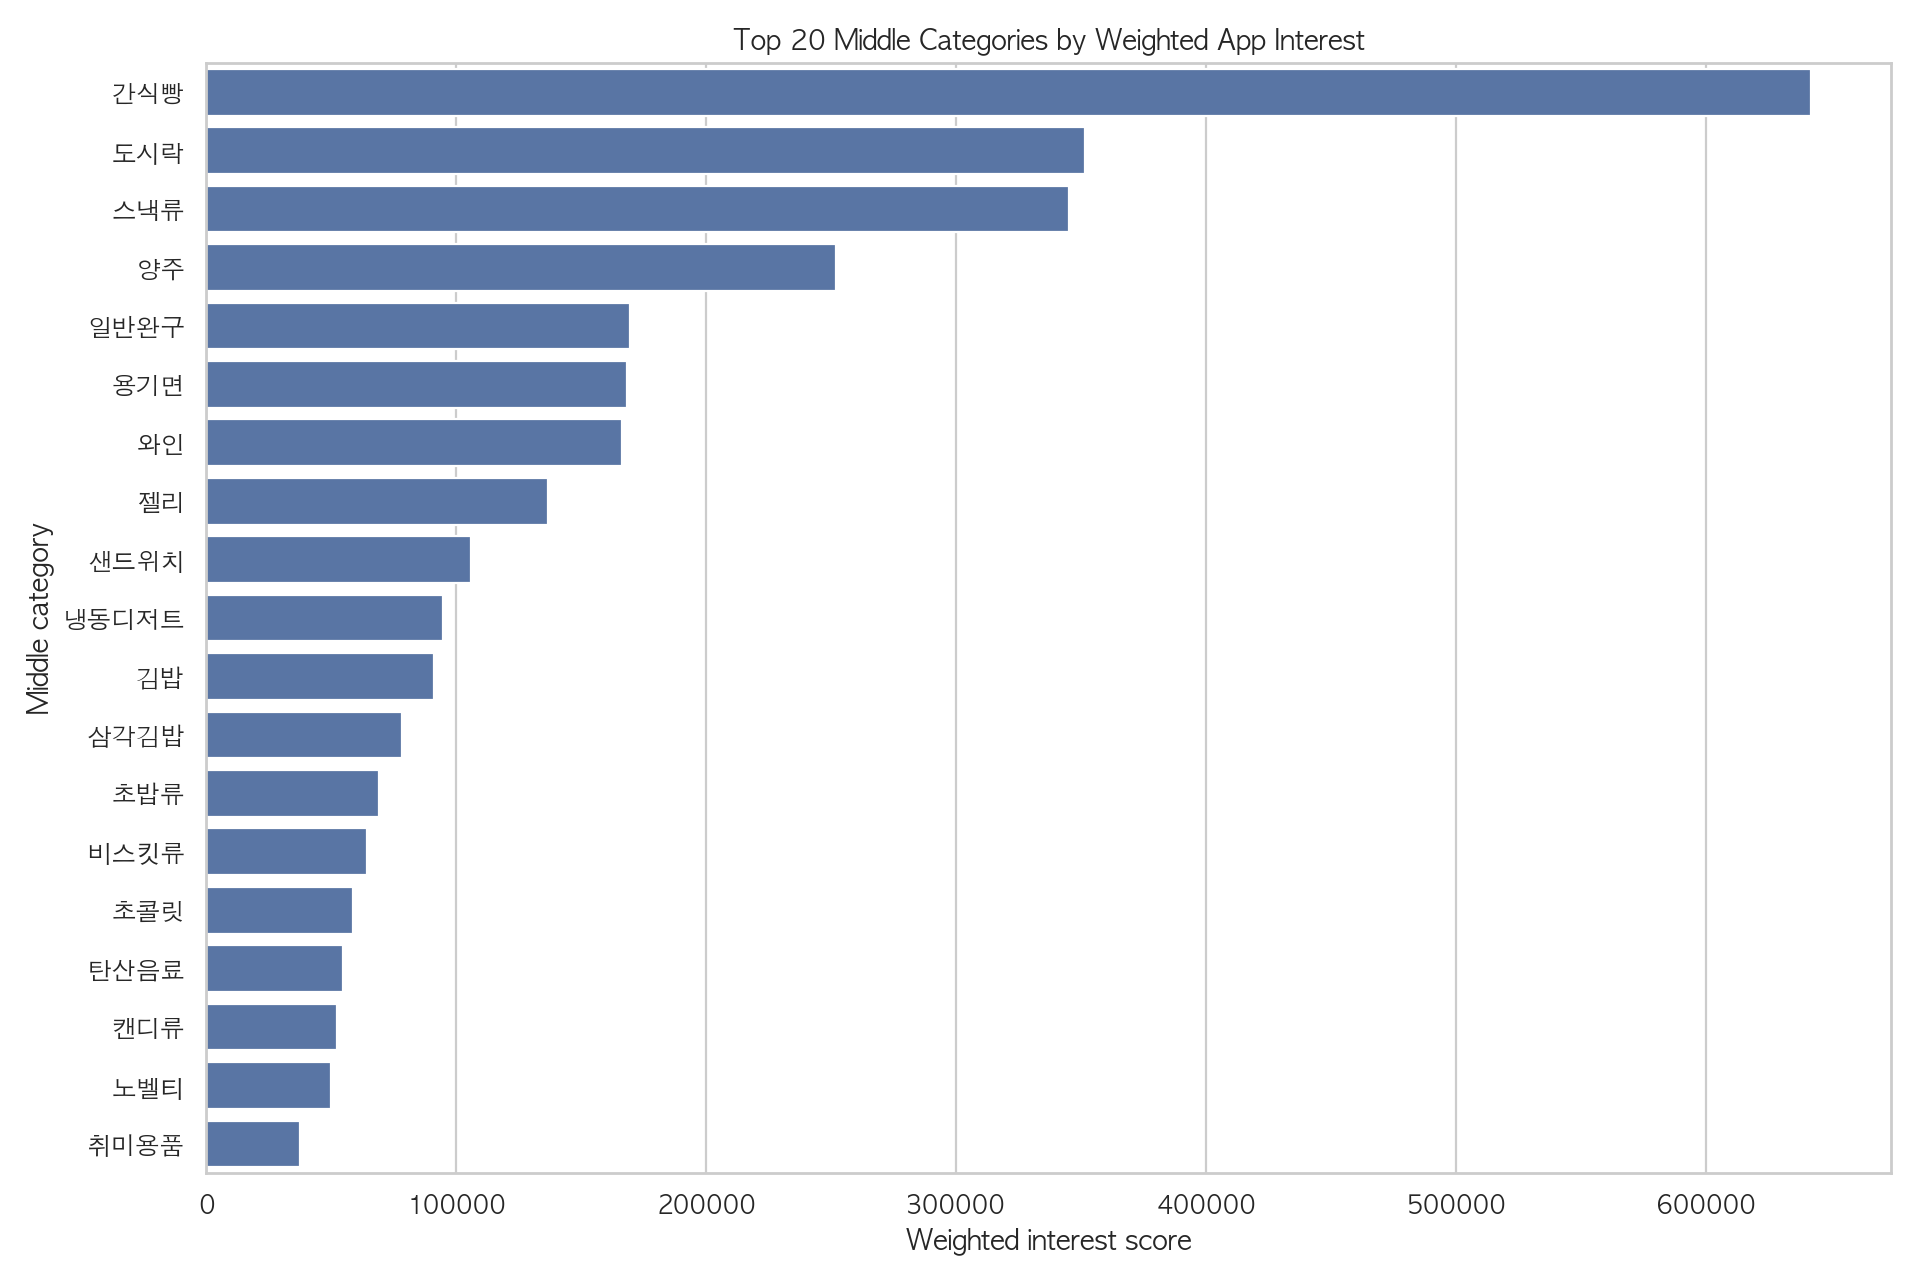

In [10]:
analysis.save_barplot(
    categories.head(20),
    x="weighted_interest_score",
    y="category_m",
    title="Top 20 Middle Categories by Weighted App Interest",
    xlabel="Weighted interest score",
    ylabel="Middle category",
    filename="top20_middle_categories_by_interest.png",
)

display(Image(filename=str(OUTPUT_DIR / "top20_middle_categories_by_interest.png")))

## 8. 월별 상품 관심도

월별로 앱 관심도 상위 상품을 확인합니다. 시즌성, 캠페인성, 신제품 후보를 나눠 보기 위한 기본 테이블입니다.

In [11]:
monthly = analysis.monthly_product_metrics(lf)
analysis.write_csv(monthly, "monthly_product_interest_metrics.csv")
analysis.write_csv(monthly.group_by("event_month").head(50), "monthly_top50_products_by_interest.csv")

monthly_cols = [
    "event_month",
    "mapped_pos_item_code",
    "mapped_item_name",
    "category_l",
    "category_m",
    "unique_users",
    "view_count",
    "cart_add_count",
    "wishlist_add_count",
    "weighted_interest_score",
    "cart_add_per_100_views",
]
monthly.select(monthly_cols).head(60)

event_month,mapped_pos_item_code,mapped_item_name,category_l,category_m,unique_users,view_count,cart_add_count,wishlist_add_count,weighted_interest_score,cart_add_per_100_views
str,str,str,str,str,u32,i64,i64,i64,f64,f64
"""2025-03""","""123923""","""신동엽)블랙서클위스키700ml""","""양주와인""","""양주""",11483,70728,1448,1868,78171.0,2.0473
"""2025-03""","""123101""","""G)오하요저지우유푸딩115g""","""디저트""","""젤리""",14095,43698,5484,1593,62653.0,12.5498
"""2025-03""","""191572""","""3월 와인 구독""",null,null,5178,25677,4148,694,39390.0,16.1545
"""2025-03""","""123618""","""렌틸콩유부초밥&에그샐러드""","""미반""","""초밥류""",6277,14059,3594,1039,26157.0,25.5637
"""2025-03""","""014387""","""맛장우전주식비빔밥""","""미반""","""도시락""",4926,12777,3954,343,24647.0,30.9462
…,…,…,…,…,…,…,…,…,…,…
"""2025-03""","""012679""","""11찬 도시락""","""미반""","""도시락""",1258,2287,538,51,3914.0,23.5243
"""2025-03""","""124510""","""우진)지오도BDM 18""","""양주와인""","""와인""",1016,2887,242,185,3896.5,8.3824
"""2025-03""","""124511""","""우진)르볼테21/22 750ml""","""양주와인""","""와인""",1056,2627,308,239,3894.0,11.7244


## 9. 월별 급상승 상품

전월 대비 `weighted_interest_score`가 크게 증가한 상품입니다. 트렌드 후보, 이벤트 반응 상품, IP/콜라보 상품 탐색에 적합합니다.

In [12]:
rising = analysis.monthly_movers(monthly)
analysis.write_csv(rising.group_by("event_month").head(100), "monthly_top100_rising_products.csv")

rising_cols = monthly_cols + [
    "prev_weighted_interest_score",
    "score_delta_vs_prev_month",
    "unique_users_delta_vs_prev_month",
]
rising.select(rising_cols).head(60)

event_month,mapped_pos_item_code,mapped_item_name,category_l,category_m,unique_users,view_count,cart_add_count,wishlist_add_count,weighted_interest_score,cart_add_per_100_views,prev_weighted_interest_score,score_delta_vs_prev_month,unique_users_delta_vs_prev_month
str,str,str,str,str,u32,i64,i64,i64,f64,f64,f64,f64,u32
"""2025-04""","""192580""","""4월 와인 구독""",null,null,4336,15679,2740,448,24700.0,17.4756,0.0,24700.0,4336
"""2025-04""","""125382""","""NCTWISH기획세트""","""과자""","""젤리류""",2406,9493,1126,362,13576.0,11.8614,0.0,13576.0,2406
"""2025-04""","""109055""","""G)크라시에유자셔벗140ml""","""아이스크림""","""고급""",4341,6676,463,219,8409.0,6.9353,0.0,8409.0,4341
"""2025-04""","""125102""","""이장우)오일스타알리오올리오""","""면""","""용기면""",1926,4213,770,184,6698.0,18.2768,0.0,6698.0,1926
"""2025-04""","""125237""","""엔시티위시2집미니앨범""","""미디어 상품""","""음반""",1923,4051,762,138,6576.5,18.8102,0.0,6576.5,1923
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2025-04""","""125084""","""PB)이봉원의봉짬뽕224g""","""냉장""","""냉장간편식""",457,850,126,53,1282.5,14.8235,0.0,1282.5,457
"""2025-04""","""108810""","""올뉴빅닭강정""","""미반""","""푸드 간편식""",653,1106,137,12,1502.5,12.387,331.0,1171.5,478
"""2025-04""","""124135""","""해태)구운버터옥수수60g""","""과자""","""스낵류""",403,651,194,34,1235.5,29.8003,68.0,1167.5,383


## 10. 월별 신규 출현 상품

해당 월에 처음 앱 상품 이벤트가 관측된 상품입니다. 출시, 노출 시작, 이벤트 진입 상품 후보로 볼 수 있습니다.

In [13]:
first_seen = analysis.first_seen_products(monthly)
analysis.write_csv(first_seen.group_by("first_month").head(100), "monthly_top100_first_seen_products.csv")

first_seen_cols = monthly_cols + ["first_month", "first_event_date_in_month"]
first_seen.select(first_seen_cols).head(60)

event_month,mapped_pos_item_code,mapped_item_name,category_l,category_m,unique_users,view_count,cart_add_count,wishlist_add_count,weighted_interest_score,cart_add_per_100_views,first_month,first_event_date_in_month
str,str,str,str,str,u32,i64,i64,i64,f64,f64,str,date
"""2025-03""","""123923""","""신동엽)블랙서클위스키700ml""","""양주와인""","""양주""",11483,70728,1448,1868,78171.0,2.0473,"""2025-03""",2025-03-01
"""2025-03""","""123101""","""G)오하요저지우유푸딩115g""","""디저트""","""젤리""",14095,43698,5484,1593,62653.0,12.5498,"""2025-03""",2025-03-01
"""2025-03""","""191572""","""3월 와인 구독""",null,null,5178,25677,4148,694,39390.0,16.1545,"""2025-03""",2025-03-01
"""2025-03""","""123618""","""렌틸콩유부초밥&에그샐러드""","""미반""","""초밥류""",6277,14059,3594,1039,26157.0,25.5637,"""2025-03""",2025-03-01
"""2025-03""","""014387""","""맛장우전주식비빔밥""","""미반""","""도시락""",4926,12777,3954,343,24647.0,30.9462,"""2025-03""",2025-03-01
…,…,…,…,…,…,…,…,…,…,…,…,…
"""2025-03""","""012679""","""11찬 도시락""","""미반""","""도시락""",1258,2287,538,51,3914.0,23.5243,"""2025-03""",2025-03-01
"""2025-03""","""124510""","""우진)지오도BDM 18""","""양주와인""","""와인""",1016,2887,242,185,3896.5,8.3824,"""2025-03""",2025-03-01
"""2025-03""","""124511""","""우진)르볼테21/22 750ml""","""양주와인""","""와인""",1056,2627,308,239,3894.0,11.7244,"""2025-03""",2025-03-01


## 11. 월별 폴더 결과 저장

월별로 개요, 이벤트 믹스, 상품/카테고리 랭킹, 급상승/신규 출현 상품을 각각 저장합니다.

In [14]:
analysis.write_by_month_outputs(lf, monthly, rising, first_seen)
print(f"Saved month-separated outputs to: {MONTH_DIR}")
sorted(path.name for path in MONTH_DIR.iterdir() if path.is_dir())

Saved month-separated outputs to: /Users/yumi/Seven-eleven/eda/app_event_yumi/outputs/product_interest_analysis/by_month


['2025_03', '2025_04', '2025_05']

## 12. 초순/중순/하순 구간별 결과 저장

3월부터 5월까지 각 월을 초순, 중순, 하순으로 나눠 같은 상품 관심도 지표를 저장합니다.

In [ ]:
analysis.write_by_period_outputs(lf)
print(f"Saved period-separated outputs to: {PERIOD_DIR}")
sorted(path.name for path in PERIOD_DIR.iterdir() if path.is_dir())

## 13. 결과 파일 확인

전체 분석 결과 폴더에 생성된 주요 CSV/PNG 목록을 확인합니다.

In [ ]:
result_files = sorted(
    path.relative_to(OUTPUT_DIR).as_posix()
    for path in OUTPUT_DIR.rglob("*")
    if path.is_file()
)
result_files[:80], len(result_files)

## 14. 다음 단계 메모

- `monthly_top100_rising_products.csv`: 트렌드/신제품 후보 발굴
- `product_interest_metrics.csv`: 상품 노드 feature 후보
- `category_interest_metrics.csv`: 카테고리 노드 feature 후보
- `clean_user_product_edges.parquet`: 사용자-상품 그래프 edge 후보

POS 판매 데이터와 결합할 때는 `mapped_pos_item_code`와 날짜 단위를 기준으로 앱 관심도와 실제 판매량의 lead-lag 관계를 검증하면 됩니다.